In [1]:
# Cell 1: Import libraries and load raw data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_PATH = '../data/raw/'

train_txn = pd.read_csv(DATA_PATH + 'train_transaction.csv')
train_id  = pd.read_csv(DATA_PATH + 'train_identity.csv')

print(f"train_transaction : {train_txn.shape}")
print(f"train_identity    : {train_id.shape}")

train_transaction : (590540, 394)
train_identity    : (144233, 41)


In [2]:
# Cell 2: Basic statistics — fraud distribution and missing values
print("=== FRAUD DISTRIBUTION ===")
fraud_counts = train_txn['isFraud'].value_counts()
print(fraud_counts)
print(f"\nFraud rate: {train_txn['isFraud'].mean()*100:.2f}%")

print("\n=== MISSING VALUE RATE (top 20 columns) ===")
missing = train_txn.isnull().mean().sort_values(ascending=False)
print(missing.head(20).apply(lambda x: f"{x*100:.1f}%"))

print("\n=== TRANSACTION AMOUNT SUMMARY ===")
print(train_txn['TransactionAmt'].describe())

=== FRAUD DISTRIBUTION ===
0    569877
1     20663
Name: isFraud, dtype: int64

Fraud rate: 3.50%

=== MISSING VALUE RATE (top 20 columns) ===
dist2    93.6%
D7       93.4%
D13      89.5%
D14      89.5%
D12      89.0%
D6       87.6%
D9       87.3%
D8       87.3%
V153     86.1%
V139     86.1%
V162     86.1%
V161     86.1%
V154     86.1%
V138     86.1%
V158     86.1%
V157     86.1%
V163     86.1%
V156     86.1%
V155     86.1%
V149     86.1%
dtype: object

=== TRANSACTION AMOUNT SUMMARY ===
count   590540.0000
mean       135.0272
std        239.1625
min          0.2510
25%         43.3210
50%         68.7690
75%        125.0000
max      31937.3910
Name: TransactionAmt, dtype: float64


In [3]:
# Cell 3: Merge transaction and identity tables, inspect ATO-relevant columns
# Left join: transactions without identity info will have NaN in identity columns
df = train_txn.merge(train_id, on='TransactionID', how='left')
print(f"Merged shape: {df.shape}")
print(f"Transactions with identity info: {df['DeviceType'].notna().mean()*100:.1f}%")

# DeviceType distribution
print("\n=== DeviceType distribution ===")
print(df['DeviceType'].value_counts(dropna=False))

# Fraud rate by DeviceType — mobile devices show higher fraud prevalence
print("\n=== Fraud rate by DeviceType ===")
print(df.groupby('DeviceType')['isFraud'].mean().apply(lambda x: f"{x*100:.2f}%"))

Merged shape: (590540, 434)
Transactions with identity info: 23.8%

=== DeviceType distribution ===
NaN        449730
desktop     85165
mobile      55645
Name: DeviceType, dtype: int64

=== Fraud rate by DeviceType ===
DeviceType
desktop     6.52%
mobile     10.17%
Name: isFraud, dtype: object


In [4]:
# Cell 4: Analyse id_31 — network/proxy anonymity signal
# id_31 is masked but known to contain browser/proxy information per competition host notes
print("=== id_31 most frequent values ===")
print(df['id_31'].value_counts().head(20))

# Cross-tabulate id_31 values with fraud rate
# High fraud rate on anonymous/proxy entries is a key ATO indicator
print("\n=== Fraud rate by id_31 value (min 100 occurrences, top 10) ===")
id31_fraud = df.groupby('id_31')['isFraud'].agg(['mean', 'count'])
id31_fraud.columns = ['fraud_rate', 'count']
id31_fraud = id31_fraud[id31_fraud['count'] > 100].sort_values('fraud_rate', ascending=False)
print(id31_fraud.head(10).assign(
    fraud_rate=lambda x: x['fraud_rate'].apply(lambda v: f"{v*100:.2f}%")
))

=== id_31 most frequent values ===
chrome 63.0                   22000
mobile safari 11.0            13423
mobile safari generic         11474
ie 11.0 for desktop            9030
safari generic                 8195
chrome 62.0                    7182
chrome 65.0                    6871
chrome 64.0                    6711
chrome 63.0 for android        5806
chrome generic                 4778
chrome 66.0                    4264
edge 16.0                      4188
chrome 64.0 for android        3473
chrome 65.0 for android        3336
firefox 57.0                   3315
mobile safari 10.0             2779
chrome 66.0 for android        2349
chrome 62.0 for android        2097
edge 15.0                      1600
chrome generic for android     1158
Name: id_31, dtype: int64

=== Fraud rate by id_31 value (min 100 occurrences, top 10) ===
                        fraud_rate  count
id_31                                    
chrome 52.0 for android     38.16%    152
opera 49.0                  

In [5]:
# Cell 5: Inspect id_01–id_11 — behavioural session features
# These columns encode login attempts, failed logins, session duration etc.
# (exact meanings masked by Vesta for privacy — inferred from competition host notes)
id_cols = [f'id_0{i}' for i in range(1, 10)] + ['id_10', 'id_11']
id_cols = [c for c in id_cols if c in df.columns]

print("=== id_01–id_11 fill rate and mean by fraud label ===")
for col in id_cols:
    filled      = df[col].notna().mean()
    mean_legit  = df[df['isFraud'] == 0][col].mean()
    mean_fraud  = df[df['isFraud'] == 1][col].mean()
    print(
        f"{col:8s}  "
        f"fill: {filled*100:5.1f}%  |  "
        f"legit mean: {mean_legit:6.2f}  |  "
        f"fraud mean: {mean_fraud:6.2f}"
    )

=== id_01–id_11 fill rate and mean by fraud label ===
id_01     fill:  24.4%  |  legit mean:  -9.67  |  fraud mean: -16.08
id_02     fill:  23.9%  |  legit mean: 172396.36  |  fraud mean: 201522.57
id_03     fill:  11.2%  |  legit mean:   0.05  |  fraud mean:   0.13
id_04     fill:  11.2%  |  legit mean:  -0.04  |  fraud mean:  -0.18
id_05     fill:  23.2%  |  legit mean:   1.63  |  fraud mean:   1.47
id_06     fill:  23.2%  |  legit mean:  -6.57  |  fraud mean:  -8.21
id_07     fill:   0.9%  |  legit mean:  13.57  |  fraud mean:  10.07
id_08     fill:   0.9%  |  legit mean: -38.15  |  fraud mean: -43.60
id_09     fill:  12.7%  |  legit mean:   0.08  |  fraud mean:   0.18
id_10     fill:  12.7%  |  legit mean:  -0.31  |  fraud mean:  -0.21
id_11     fill:  23.9%  |  legit mean:  99.74  |  fraud mean:  99.78


=== TransactionDT range ===
Min : 86,400
Max : 15,811,131
Span: 182 days


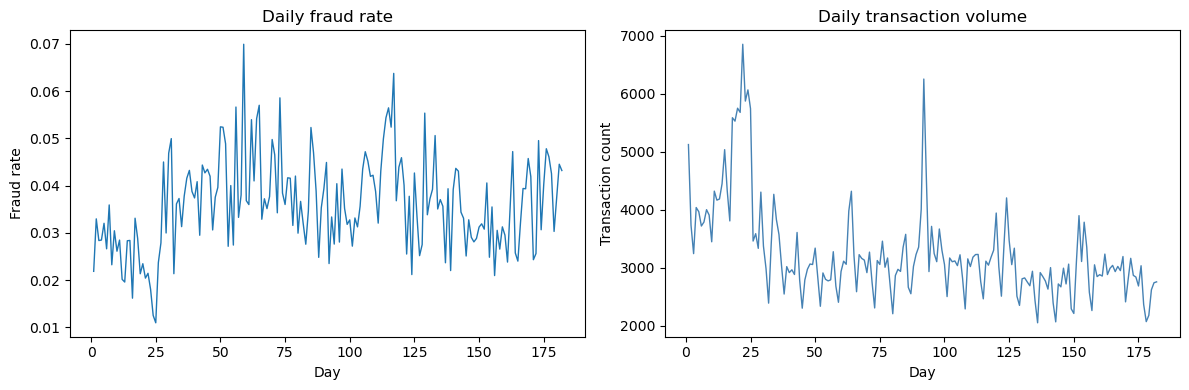

Saved: outputs/figures/daily_fraud_trend.png


In [6]:
# Cell 6: Analyse TransactionDT — timedelta from an undisclosed reference date
# Not a real timestamp; used for ordering transactions within each card sequence
print("=== TransactionDT range ===")
print(f"Min : {df['TransactionDT'].min():,}")
print(f"Max : {df['TransactionDT'].max():,}")
print(f"Span: {(df['TransactionDT'].max() - df['TransactionDT'].min()) / 86400:.0f} days")

# Approximate daily fraud rate trend
df['day'] = (df['TransactionDT'] // 86400).astype(int)
daily = df.groupby('day')['isFraud'].agg(['mean', 'count']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(daily['day'], daily['mean'], linewidth=1)
axes[0].set_title('Daily fraud rate')
axes[0].set_xlabel('Day'); axes[0].set_ylabel('Fraud rate')

axes[1].plot(daily['day'], daily['count'], linewidth=1, color='steelblue')
axes[1].set_title('Daily transaction volume')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Transaction count')

plt.tight_layout()
plt.savefig('../outputs/figures/daily_fraud_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/daily_fraud_trend.png")

=== Transactions per card (UID) ===
count   39974.0000
mean       14.7731
std       106.6799
min         1.0000
25%         1.0000
50%         2.0000
75%         7.0000
max      9928.0000
Name: txn_count, dtype: float64

Cards with at least 1 fraud transaction : 3,439
Cards with identity information          : 53.7%


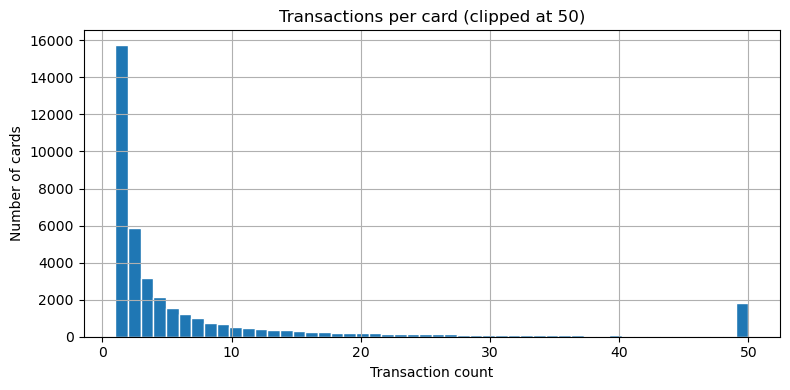

Saved: outputs/figures/txn_per_card.png


In [7]:
# Cell 7: Build user identifier (UID) and sort by card + time
# UID = card1 + addr1 combination — approximates a unique account
# Sorting by UID and TransactionDT is essential before building LSTM sequences
df['uid'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
df = df.sort_values(['uid', 'TransactionDT']).reset_index(drop=True)

uid_stats = df.groupby('uid').agg(
    txn_count    = ('TransactionID', 'count'),
    fraud_count  = ('isFraud', 'sum'),
    has_identity = ('DeviceType', lambda x: x.notna().any())
).reset_index()

print("=== Transactions per card (UID) ===")
print(uid_stats['txn_count'].describe())

print(f"\nCards with at least 1 fraud transaction : {(uid_stats['fraud_count'] > 0).sum():,}")
print(f"Cards with identity information          : {uid_stats['has_identity'].mean()*100:.1f}%")

# Distribution of transaction counts per card
plt.figure(figsize=(8, 4))
uid_stats['txn_count'].clip(upper=50).hist(bins=50, edgecolor='white')
plt.title('Transactions per card (clipped at 50)')
plt.xlabel('Transaction count'); plt.ylabel('Number of cards')
plt.tight_layout()
plt.savefig('../outputs/figures/txn_per_card.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/txn_per_card.png")

In [8]:
# Cell 8: Save merged dataframe and print EDA summary
# Parquet format chosen for speed and compression — ~10x faster than CSV for downstream reads
df.to_parquet('../data/processed/df_merged.parquet', index=False)
print("Saved: data/processed/df_merged.parquet")

print("\n=== EDA SUMMARY ===")
print(f"Total transactions       : {len(df):,}")
print(f"Total columns            : {df.shape[1]}")
print(f"Fraud rate               : {df['isFraud'].mean()*100:.2f}%")
print(f"Transactions with identity: {df['DeviceType'].notna().mean()*100:.1f}%")
print(f"Unique UIDs              : {df['uid'].nunique():,}")
print(f"\nNext step -> 02_proxy_label.ipynb")

Saved: data/processed/df_merged.parquet

=== EDA SUMMARY ===
Total transactions       : 590,540
Total columns            : 436
Fraud rate               : 3.50%
Transactions with identity: 23.8%
Unique UIDs              : 39,974

Next step -> 02_proxy_label.ipynb
